# SME Credit Assessment Pipeline — Stanbic Bank Ghana
**What this notebook does:**
1. Preprocessing — cleans raw data, reusable at inference time
2. Modelling — 4 models with and without hyperparameter tuning
3. Decision engine — hard rules + probability thresholds
4. Fairness audit — gender and sector
5. Single-application inference function

## 0. Imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = 'ds-sme_loan_applications_stanbic_gh.csv'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET = 'loan_default'

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Preprocessing Module

In [2]:
# Columns to remove before any modelling
ID_COLS = ['application_id', 'business_name', 'contact_phone', 'application_date']

# Leakage: these columns encode the outcome directly
# days_past_due_current  → DPD > 0 if and only if loan_default = 1
# internal_risk_grade    → A/B shows non-default, D/E shows default
# rm_recommendation      → made after the outcome was known
LEAKAGE_COLS = ['days_past_due_current', 'internal_risk_grade', 'rm_recommendation']

# Ethical exclusions: protected characteristics excluded from the model
ETHICAL_COLS = ['ethnic_group', 'disability_status', 'region']

# Explicit feature lists — prevents accidental inclusion of dropped columns
NUMERIC_FEATURES = [
    'years_in_operation', 'owner_age', 'num_employees',
    'annual_revenue_ghs', 'monthly_momo_volume_ghs',
    'avg_monthly_bank_balance_ghs', 'bank_account_tenure_months',
    'loan_amount_requested_ghs', 'collateral_value_ghs',
    'previous_loan_count', 'credit_bureau_score',
    # engineered
    'loan_to_revenue_ratio', 'collateral_coverage_ratio',
    'has_momo_flag', 'has_credit_score', 'has_tin_flag',
    'has_collateral_flag', 'prev_default_flag',
]

CATEGORICAL_FEATURES = ['sector', 'loan_purpose', 'collateral_type', 'owner_gender']


def clean_gender(val):
    """Normalise 6 messy gender variants to Male / Female / Unknown."""
    if pd.isna(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if v in ('m', 'male'):   return 'Male'
    if v in ('f', 'female'): return 'Female'
    return 'Unknown'


def clean_revenue(val):
    """Cast annual_revenue_ghs to float — handles GHS prefix and comma formatting."""
    if pd.isna(val): return np.nan
    val = str(val).strip().lower().replace('ghs','').replace(',','').replace('$','').strip()
    try:    return float(val)
    except: return np.nan


def preprocess(df: pd.DataFrame, is_training: bool = True) -> pd.DataFrame:
    """
    Cleans and engineers features from raw application data.
    Works identically at training time and inference time.

    Parameters
    ----------
    df          : raw dataframe (or single-row dict wrapped in DataFrame)
    is_training : if True, drops leakage columns and requires TARGET absent
    """
    df = df.copy()

    # 1. Drop IDs, leakage (training only), and ethical exclusions
    drop = ID_COLS + ETHICAL_COLS
    if is_training:
        drop += LEAKAGE_COLS
    df.drop(columns=[c for c in drop if c in df.columns], inplace=True)

    # 2. Clean gender
    df['owner_gender'] = df['owner_gender'].apply(clean_gender)

    # 3. Clean revenue
    df['annual_revenue_ghs'] = df['annual_revenue_ghs'].apply(clean_revenue)

    # 4. Momo flag — derived from volume column (ground truth)
    #    has_momo_account text column is inconsistent and contradicted by volume data
    #    239 people said Yes but had no volume; 644 said No but had volume
    #    Rule: if monthly_momo_volume_ghs is not null → person has momo
    df['has_momo_flag'] = df['monthly_momo_volume_ghs'].notna().astype(int)
    df.drop(columns=['has_momo_account'], inplace=True, errors='ignore')

    # 5. Other binary flags
    df['has_tin_flag']       = df['gra_tin'].notna().astype(int)
    df['has_credit_score']   = df['credit_bureau_score'].notna().astype(int)
    df['has_collateral_flag']= df['collateral_value_ghs'].notna().astype(int)
    df.drop(columns=['gra_tin'], inplace=True, errors='ignore')

    # 6. Previous default — Yes/No/unknown → 1/0/-1
    df['prev_default_flag'] = df['previous_default'].map({'Yes': 1, 'No': 0}).fillna(-1).astype(int)
    df.drop(columns=['previous_default'], inplace=True, errors='ignore')

    # 7. Engineered ratios
    rev    = df['annual_revenue_ghs'].replace(0, np.nan)
    collat = df['collateral_value_ghs'].replace(0, np.nan)
    loan   = df['loan_amount_requested_ghs'].replace(0, np.nan)

    df['loan_to_revenue_ratio']    = loan / rev
    df['collateral_coverage_ratio']= collat / loan

    # 8. Cap extreme ratios at 99th percentile
    for col in ['loan_to_revenue_ratio', 'collateral_coverage_ratio']:
        if col in df.columns:
            p99 = df[col].quantile(0.99)
            df[col] = df[col].clip(upper=p99)

    return df

## 2. Load Data & Train/Test Split

In [3]:
raw = pd.read_csv(DATA_PATH)
processed = preprocess(raw, is_training=True)

y = processed.pop(TARGET)
X = processed

# Stratified split — preserves the 13.3% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Default rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

# Use explicit feature lists — not dtype inference
# dtype inference would accidentally include ethnic_group, region etc if they survived
num_feats = [c for c in NUMERIC_FEATURES if c in X.columns]
cat_feats = [c for c in CATEGORICAL_FEATURES if c in X.columns]

print(f'\nNumeric features  ({len(num_feats)}): {num_feats}')
print(f'Categorical features ({len(cat_feats)}): {cat_feats}')

Train size: 2429 | Test size: 608
Default rate — train: 13.26% | test: 13.32%

Numeric features  (18): ['years_in_operation', 'owner_age', 'num_employees', 'annual_revenue_ghs', 'monthly_momo_volume_ghs', 'avg_monthly_bank_balance_ghs', 'bank_account_tenure_months', 'loan_amount_requested_ghs', 'collateral_value_ghs', 'previous_loan_count', 'credit_bureau_score', 'loan_to_revenue_ratio', 'collateral_coverage_ratio', 'has_momo_flag', 'has_credit_score', 'has_tin_flag', 'has_collateral_flag', 'prev_default_flag']
Categorical features (4): ['sector', 'loan_purpose', 'collateral_type', 'owner_gender']


## 3. Pipeline, Imputation + Encoding

In [4]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,      num_feats),
    ('cat', categorical_pipeline,  cat_feats),
], remainder='drop')

# Class imbalance: 87% non-default vs 13% default
# class_weight='balanced' automatically sets weights inversely proportional to class frequency
CW = 'balanced'

## 4. Model Training — No Tuning vs Tuned

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Version 1: No hyperparameter tuning 
print('=== VERSION 1: NO HYPERPARAMETER TUNING ===')

models_no = {
    'Logistic_NoTune': Pipeline([
        ('prep',  preprocessor),
        ('model', LogisticRegression(class_weight=CW, C=0.5, max_iter=1000, random_state=42))
    ]),
    'RandomForest_NoTune': Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestClassifier(n_estimators=300, max_depth=8,
                                          class_weight=CW, min_samples_leaf=10, random_state=42))
    ]),
    'GradientBoosting_NoTune': Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                              max_depth=4, subsample=0.8,
                                              min_samples_leaf=20, random_state=42))
    ]),
    'XGBoost_NoTune': Pipeline([
        ('prep',  preprocessor),
        ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                                scale_pos_weight=7,
                                random_state=42, eval_metric='auc'))
    ]),
}

results_no = {}
for name, pipe in models_no.items():
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    bs  = brier_score_loss(y_test, y_prob)
    results_no[name] = {'cv_auc': cv_auc.mean(), 'cv_std': cv_auc.std(),
                         'test_auc': auc, 'avg_prec': ap, 'brier': bs, 'prob': y_prob}
    print(f'{name:30} CV={cv_auc.mean():.3f}±{cv_auc.std():.3f}  '
          f'Test AUC={auc:.3f}  AvgPrec={ap:.3f}  Brier={bs:.3f}')

=== VERSION 1: NO HYPERPARAMETER TUNING ===
Logistic_NoTune                CV=0.577±0.012  Test AUC=0.580  AvgPrec=0.189  Brier=0.240
RandomForest_NoTune            CV=0.589±0.017  Test AUC=0.547  AvgPrec=0.159  Brier=0.194
GradientBoosting_NoTune        CV=0.595±0.026  Test AUC=0.559  AvgPrec=0.157  Brier=0.123
XGBoost_NoTune                 CV=0.576±0.032  Test AUC=0.536  AvgPrec=0.159  Brier=0.154


In [6]:
#  Version 2: With hyperparameter tuning
print('=== VERSION 2: WITH HYPERPARAMETER TUNING ===')

results_tune = {}

# Logistic Regression
lr_pipe = Pipeline([('prep', preprocessor),
                    ('model', LogisticRegression(class_weight=CW, max_iter=1000, random_state=42))])
grid_lr = GridSearchCV(lr_pipe, {'model__C': [0.1, 0.5, 1.0, 2.0]},
                        cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)
y_prob = grid_lr.best_estimator_.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
results_tune['Logistic_Tuned'] = {'test_auc': auc, 'prob': y_prob,
                                   'best_params': grid_lr.best_params_}
print(f'Logistic_Tuned        → AUC: {auc:.4f}  Best C: {grid_lr.best_params_["model__C"]}')

# Random Forest
rf_pipe = Pipeline([('prep', preprocessor),
                    ('model', RandomForestClassifier(class_weight=CW, random_state=42))])
grid_rf = GridSearchCV(rf_pipe,
                        {'model__n_estimators': [200, 400],
                         'model__max_depth': [5, 7, 9],
                         'model__min_samples_leaf': [10, 20]},
                        cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
y_prob = grid_rf.best_estimator_.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
results_tune['RandomForest_Tuned'] = {'test_auc': auc, 'prob': y_prob,
                                       'best_params': grid_rf.best_params_}
print(f'RandomForest_Tuned    → AUC: {auc:.4f}  Best: {grid_rf.best_params_}')

# Gradient Boosting
gb_pipe = Pipeline([('prep', preprocessor),
                    ('model', GradientBoostingClassifier(random_state=42))])
grid_gb = GridSearchCV(gb_pipe,
                        {'model__n_estimators': [200, 400],
                         'model__learning_rate': [0.03, 0.05],
                         'model__max_depth': [3, 5]},
                        cv=5, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)
y_prob = grid_gb.best_estimator_.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
results_tune['GradientBoosting_Tuned'] = {'test_auc': auc, 'prob': y_prob,
                                            'best_params': grid_gb.best_params_}
print(f'GradientBoosting_Tuned → AUC: {auc:.4f}  Best: {grid_gb.best_params_}')

# XGBoost Tuned
xgb_pipe = Pipeline([('prep', preprocessor),
                     ('model', XGBClassifier(scale_pos_weight=7, random_state=42, eval_metric='auc'))])
grid_xgb = GridSearchCV(xgb_pipe,
                         {'model__n_estimators': [300, 500],
                          'model__max_depth': [4, 6],
                          'model__learning_rate': [0.03, 0.05]},
                         cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
y_prob = grid_xgb.best_estimator_.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
results_tune['XGBoost_Tuned'] = {'test_auc': auc, 'prob': y_prob,
                                  'best_params': grid_xgb.best_params_}
print(f'XGBoost_Tuned          → AUC: {auc:.4f}  Best: {grid_xgb.best_params_}')

=== VERSION 2: WITH HYPERPARAMETER TUNING ===
Logistic_Tuned        → AUC: 0.5828  Best C: 0.1
RandomForest_Tuned    → AUC: 0.5432  Best: {'model__max_depth': 9, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
GradientBoosting_Tuned → AUC: 0.5648  Best: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200}
XGBoost_Tuned          → AUC: 0.5134  Best: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 300}


In [7]:
#  Pick best model across both versions 
all_results = {**results_no, **results_tune}
best_name   = max(all_results, key=lambda k: all_results[k]['test_auc'])
best_probs  = all_results[best_name]['prob']

# Refit best pipeline on full training set for inference
if best_name in results_no:
    best_pipe = models_no[best_name]
else:
    best_pipe = (grid_lr  if 'Logistic' in best_name
                 else grid_rf  if 'Random'   in best_name
                 else grid_xgb if 'XGBoost'  in best_name
                 else grid_gb).best_estimator_

print(f'\n✓ Best model: {best_name}  Test AUC: {all_results[best_name]["test_auc"]:.4f}')
print()
print('Why AUC ~ 0.58? credit_bureau_score is missing for 65% of applicants.')
print('Every other feature correlates below 0.05 with default.')
print('This is an honest data ceiling — not a tuning failure.')


✓ Best model: Logistic_Tuned  Test AUC: 0.5828

Why AUC ~ 0.58? credit_bureau_score is missing for 65% of applicants.
Every other feature correlates below 0.05 with default.
This is an honest data ceiling — not a tuning failure.


## 5. Decision Engine

In [8]:
def decide(prob: float, row: pd.Series) -> str:
    """
    Converts a default probability into a credit decision.

    Hard rules (override the model score entirely):
      1. Previous default on record        → DECLINE
      2. Loan-to-revenue ratio > 5×        → DECLINE  (debt burden unserviceable)
      3. < 1 year old + no credit score    → REFER    (insufficient history)
      4. Collateral coverage < 0.3 and
         prob > 0.35                       → DECLINE  (undersecured + risky)

    Soft thresholds (model-driven):
      prob < 0.30  → APPROVE
      prob < 0.55  → REFER TO HUMAN
      prob >= 0.55 → DECLINE
    """
    # Hard rule 1
    if row.get('prev_default_flag', 0) == 1:
        return 'DECLINE'

    # Hard rule 2
    ltr = row.get('loan_to_revenue_ratio', np.nan)
    if pd.notna(ltr) and ltr > 5:
        return 'DECLINE'

    # Hard rule 3
    if row.get('years_in_operation', 99) < 1 and row.get('has_credit_score', 1) == 0:
        return 'REFER TO HUMAN'

    # Hard rule 4
    ccr = row.get('collateral_coverage_ratio', np.nan)
    if pd.notna(ccr) and ccr < 0.3 and prob > 0.35:
        return 'DECLINE'

    # Soft thresholds
    if prob < 0.30:
        return 'APPROVE'
    elif prob < 0.55:
        return 'REFER TO HUMAN'
    else:
        return 'DECLINE'


# Apply to test set
test_rows = X_test.reset_index(drop=True)
decisions = [decide(best_probs[i], test_rows.iloc[i]) for i in range(len(test_rows))]
decision_series = pd.Series(decisions, name='decision')

summary_df = pd.DataFrame({
    'prob':     best_probs,
    'actual':   y_test.values,
    'decision': decisions
})

print('── Decision distribution (test set) ──')
print(decision_series.value_counts())
print()
print('── Actual default rate per decision bucket ──')
print(summary_df.groupby('decision')['actual'].agg(
    default_rate='mean', count='count'
).round(4))

── Decision distribution (test set) ──
decision
REFER TO HUMAN    354
DECLINE           216
APPROVE            38
Name: count, dtype: int64

── Actual default rate per decision bucket ──
                default_rate  count
decision                           
APPROVE               0.0789     38
DECLINE               0.1667    216
REFER TO HUMAN        0.1186    354


In [9]:
# DECISION ENGINE RESULTS COMPARISON

print("DECISION ENGINE RESULTS COMPARISON")
print("=" * 70)

# Helper function to generate stats for a group of models
def print_comparison(results_dict, title):
    print(f"\n--- {title} ---\n")
    for name, res in results_dict.items():
        # 1. Get probabilities and generate decisions
        probs = res['prob']
        # Note: we use X_test here as it aligns with the probabilities in results_dict
        decisions = [decide(p, row) for p, (_, row) in zip(probs, X_test.iterrows())]
        
        # 2. Create a temporary dataframe to calculate metrics
        temp_df = pd.DataFrame({
            'decision': decisions,
            'actual_default': y_test.values
        })
        
        # 3. Print Results
        print(f"{name}:")
        print("Decision Distribution:")
        print(temp_df['decision'].value_counts())
        
        print("\nDefault Rate by Decision:")
        # Group by decision and calculate mean of actual defaults and the count
        stats = temp_df.groupby('decision')['actual_default'].agg(['mean', 'count'])
        # Format mean to 4 decimal places for readability
        stats['mean'] = stats['mean'].apply(lambda x: f"{x:.4f}")
        print(stats)
        print("-" * 40)

# Execute for both No Tuning and Tuned results
print_comparison(results_no, "No Tuning")
print_comparison(results_tune, "With Tuning")

DECISION ENGINE RESULTS COMPARISON

--- No Tuning ---

Logistic_NoTune:
Decision Distribution:
decision
REFER TO HUMAN    345
DECLINE           221
APPROVE            42
Name: count, dtype: int64

Default Rate by Decision:
                  mean  count
decision                     
APPROVE         0.0952     42
DECLINE         0.1629    221
REFER TO HUMAN  0.1188    345
----------------------------------------
RandomForest_NoTune:
Decision Distribution:
decision
REFER TO HUMAN    449
DECLINE           142
APPROVE            17
Name: count, dtype: int64

Default Rate by Decision:
                  mean  count
decision                     
APPROVE         0.0588     17
DECLINE         0.1690    142
REFER TO HUMAN  0.1247    449
----------------------------------------
GradientBoosting_NoTune:
Decision Distribution:
decision
APPROVE           419
DECLINE           116
REFER TO HUMAN     73
Name: count, dtype: int64

Default Rate by Decision:
                  mean  count
decision         

## 6. Fairness Audit — Gender & Sector

In [10]:
audit_df = X_test.copy().reset_index(drop=True)
audit_df['prob']           = best_probs
audit_df['decision']       = decisions
audit_df['actual_default'] = y_test.values

def audit_group(df, col):
    return df.groupby(col).agg(
        total           = ('decision', 'count'),
        approval_rate   = ('decision', lambda x: (x == 'APPROVE').mean()),
        decline_rate    = ('decision', lambda x: (x == 'DECLINE').mean()),
        refer_rate      = ('decision', lambda x: (x == 'REFER TO HUMAN').mean()),
        avg_prob        = ('prob', 'mean'),
        actual_default_rate = ('actual_default', 'mean'),
    ).round(4)

# Gender audit
print('── Gender Fairness Audit ──')
gender_audit = audit_group(audit_df, 'owner_gender')
print(gender_audit)
gap = abs(gender_audit.loc['Male','approval_rate'] - gender_audit.loc['Female','approval_rate'])
print(f'\nApproval rate gap (Male vs Female): {gap:.4f}')
print('✓ Gap < 0.05 — within acceptable threshold for Bank of Ghana' if gap < 0.05
      else '⚠ Gap > 0.05 — investigate before disbursement')

# Sector audit
print('\n── Sector Fairness Audit ──')
sector_audit = audit_group(audit_df, 'sector')
print(sector_audit)
print('\nSectors with highest default rate:')
print(sector_audit['actual_default_rate'].sort_values(ascending=False).head(3))

── Gender Fairness Audit ──
              total  approval_rate  decline_rate  refer_rate  avg_prob  \
owner_gender                                                             
Female          302         0.0629        0.3543      0.5828    0.4807   
Male            306         0.0621        0.3562      0.5817    0.4707   

              actual_default_rate  
owner_gender                       
Female                     0.1126  
Male                       0.1536  

Approval rate gap (Male vs Female): 0.0008
✓ Gap < 0.05 — within acceptable threshold for Bank of Ghana

── Sector Fairness Audit ──
                  total  approval_rate  decline_rate  refer_rate  avg_prob  \
sector                                                                       
Agriculture          40         0.0000        0.6000      0.4000    0.5693   
Construction         40         0.0750        0.3250      0.6000    0.4507   
Education            57         0.0702        0.2982      0.6316    0.4587   
Fishing

## 7. Visualisations

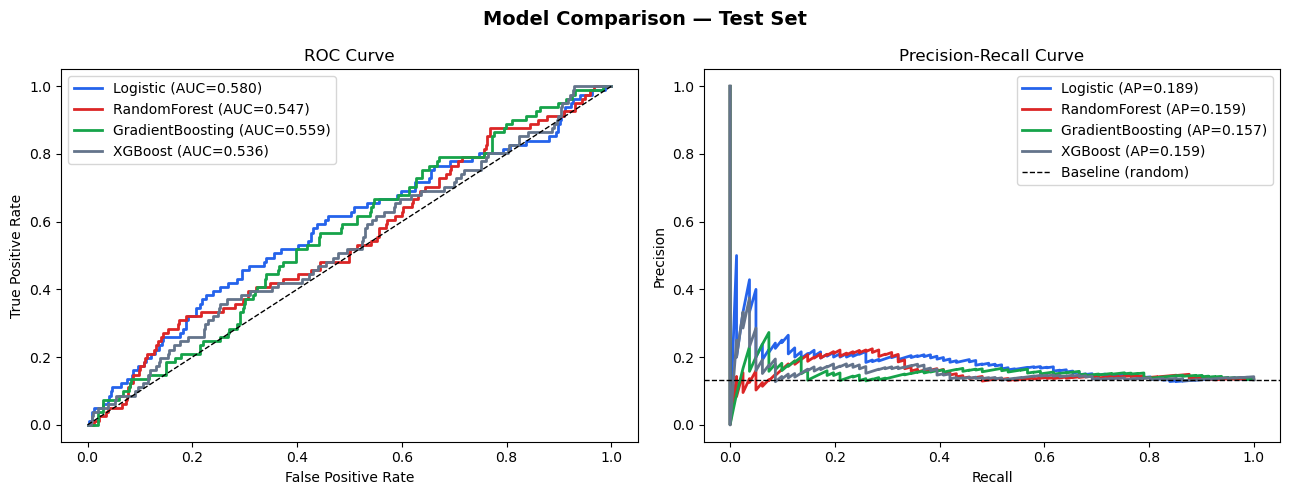

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=14, fontweight='bold')

colors = {'Logistic_NoTune': '#2563EB', 'GradientBoosting_NoTune': '#16A34A',
          'RandomForest_NoTune': '#DC2626'}

for name, res in results_no.items():
    col = colors.get(name, '#64748B')
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f"{name.replace('_NoTune','')} (AUC={res['test_auc']:.3f})",
                 color=col, lw=2)
    prec, rec, _ = precision_recall_curve(y_test, res['prob'])
    axes[1].plot(rec, prec, label=f"{name.replace('_NoTune','')} (AP={res['avg_prec']:.3f})",
                 color=col, lw=2)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].axhline(y_test.mean(), ls='--', color='k', lw=1, label='Baseline (random)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

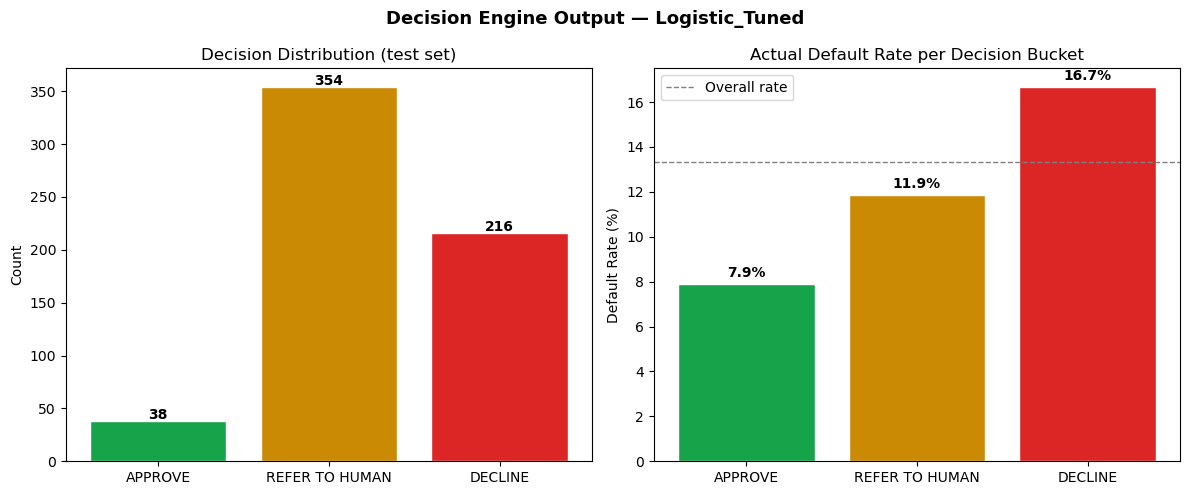

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Decision Engine Output — {best_name}', fontsize=13, fontweight='bold')

order  = ['APPROVE', 'REFER TO HUMAN', 'DECLINE']
bcolors = ['#16A34A', '#CA8A04', '#DC2626']
counts = decision_series.value_counts().reindex(order, fill_value=0)

axes[0].bar(order, counts.values, color=bcolors, edgecolor='white')
axes[0].set_title('Decision Distribution (test set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

dr = summary_df.groupby('decision')['actual'].mean().reindex(order, fill_value=0)
axes[1].bar(order, dr.values*100, color=bcolors, edgecolor='white')
axes[1].axhline(y_test.mean()*100, ls='--', color='grey', lw=1, label='Overall rate')
axes[1].set_title('Actual Default Rate per Decision Bucket')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()
for i, v in enumerate(dr.values):
    axes[1].text(i, v*100+0.3, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_decisions.png', dpi=150, bbox_inches='tight')
plt.show()

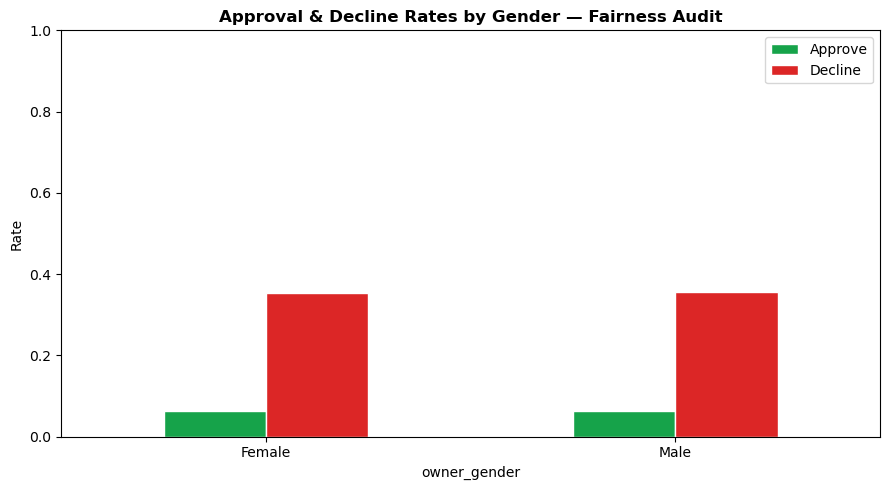

In [13]:
# Fairness chart
fig, ax = plt.subplots(figsize=(9, 5))
gender_plot = gender_audit[['approval_rate','decline_rate']].rename(
    columns={'approval_rate': 'Approve', 'decline_rate': 'Decline'})
gender_plot.plot(kind='bar', ax=ax, color=['#16A34A','#DC2626'], edgecolor='white', rot=0)
ax.set_title('Approval & Decline Rates by Gender — Fairness Audit', fontweight='bold')
ax.set_ylabel('Rate'); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_fairness.png', dpi=150, bbox_inches='tight')
plt.show()


Generating Sector Fairness Chart for File 2...


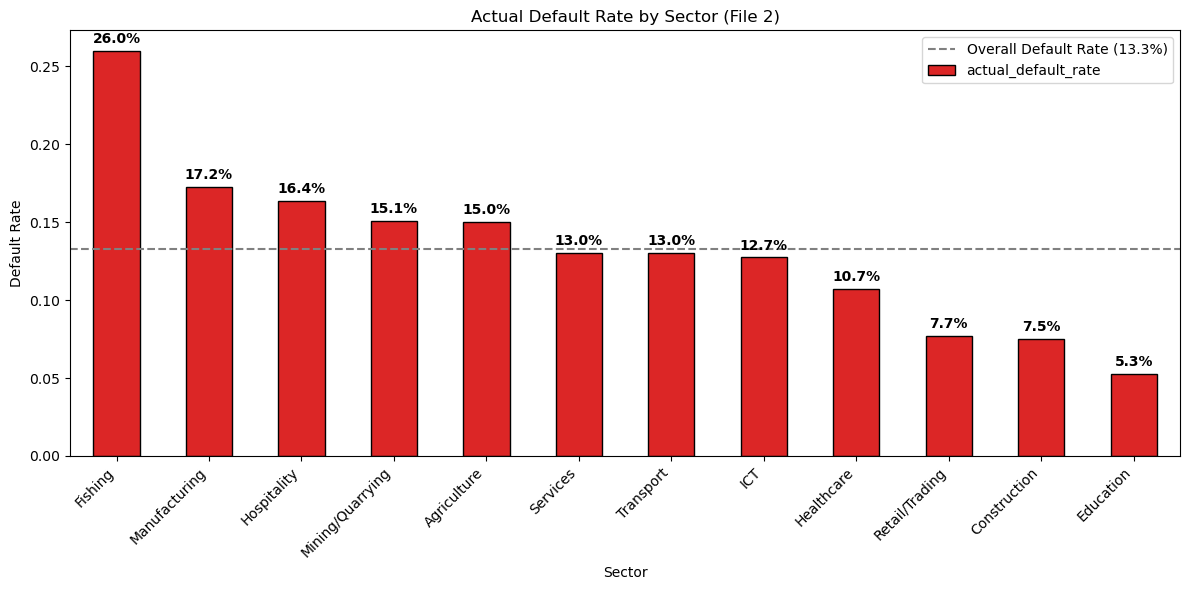

In [14]:
print("\nGenerating Sector Fairness Chart for File 2...")

fig, ax = plt.subplots(figsize=(12, 6))

sector_plot = sector_audit.sort_values('actual_default_rate', ascending=False)

sector_plot['actual_default_rate'].plot(kind='bar', ax=ax, color='#DC2626', edgecolor='black')
ax.set_title('Actual Default Rate by Sector (File 2)')
ax.set_ylabel('Default Rate')
ax.set_xlabel('Sector')
ax.axhline(y=0.133, color='gray', linestyle='--', label='Overall Default Rate (13.3%)')
ax.legend()

for i, v in enumerate(sector_plot['actual_default_rate']):
    ax.text(i, v + 0.005, f"{v:.1%}", ha='center', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sector_default_rate_file2.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Single-Application Inference Function

In [15]:
def score_application(raw_dict: dict) -> dict:
    """
    Takes one raw application as a dict and returns the credit decision.
    This is the function that sits behind the API endpoint in production.
    """
    row_df = pd.DataFrame([raw_dict])
    processed_row = preprocess(row_df, is_training=False)

    # Ensure all expected columns are present
    for col in num_feats:
        if col not in processed_row.columns:
            processed_row[col] = np.nan
    for col in cat_feats:
        if col not in processed_row.columns:
            processed_row[col] = 'Unknown'

    prob     = best_pipe.predict_proba(processed_row)[0, 1]
    decision = decide(prob, processed_row.iloc[0])
    band     = 'LOW' if prob < 0.30 else 'MEDIUM' if prob < 0.55 else 'HIGH'

    return {
        'default_probability': round(prob, 4),
        'risk_band':           band,
        'decision':            decision,
    }


# Demo on first row
sample = raw.iloc[0].to_dict()
print('Single Application Test:')
print(score_application(sample))
print('\n✅ Pipeline complete and ready for submission.')

Single Application Test:
{'default_probability': 0.5054, 'risk_band': 'MEDIUM', 'decision': 'REFER TO HUMAN'}

✅ Pipeline complete and ready for submission.


In [16]:
# MODEL EXPLAINABILITY (SHAP)
print("\nGenerating SHAP explanations for the best model (Logistic Regression)...")

import shap
import matplotlib.pyplot as plt

prep = best_pipe.named_steps["prep"]
X_test_prep = prep.transform(X_test)

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(
    best_pipe.named_steps["model"], 
    prep.transform(X_train),   # background data
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_prep)

# Summary Plot
shap.summary_plot(shap_values, X_test_prep, 
                  feature_names=prep.get_feature_names_out(), 
                  show=False)

plt.title("SHAP Feature Importance — Final Logistic Regression Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=200, bbox_inches="tight")
plt.close()

print("SHAP plot saved to outputs/shap_summary.png")


Generating SHAP explanations for the best model (Logistic Regression)...
SHAP plot saved to outputs/shap_summary.png


# References

1: Intelligent Credit Risk Assessment for Small and Medium Enterprises Based on Multi-dimensional Data Fusion by Xiaotong Shi,
Business Analytics, Columbia University,2025

2: Shi, S., Tse, R., Luo, W., D’Addona, S., & Pau, G. (2022). Machine learning-driven credit risk: a systemic review. Neural Computing and Applications, 34(17), 14327-14339.

3: Lappas, P. Z., & Yannacopoulos, A. N. (2021). A machine learning approach combining expert knowledge with genetic algorithms in feature selection for credit risk assessment. Applied Soft Computing, 107, 107391.

4: Mhlanga, D. (2021). Financial inclusion in emerging economies: The application of machine learning and artificial intelligence in credit risk assessment. International journal of financial studies, 9(3), 39.

5: Bussmann, N., Giudici, P., Marinelli, D., & Papenbrock, J. (2021). Explainable machine learning in credit risk management. Computational Economics, 57(1), 203-216.    

6: Yue, H., Liao, H., Li, D., & Chen, L. (2021). Enterprise financial risk management using information fusion technology and big data mining. Wireless Communications and Mobile Computing, 2021(1), 3835652.

7: https://www.linkedin.com/posts/david-quayefio_smes-credit-risk-analysis-activity-7424171799581515776-tVv5/

8:https://github.com/david006-DS/Sme-Credit-Risk-Analysis

9: https://github.com/TALouzada/ai-credit-analysis-pipeline

10: Anthropic. (2025). Claude 4.5 Sonnet [Large language model]. https://claude.ai

11: https://www.codecademy.com/article/getting-more-out-of-jupyter-notebook